In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, wilcoxon
import os, pickle
import matplotlib as mpl
import scipy.special

In [2]:
def change_font(font_size = 10, font_choice = False):
    '''
    Custom function for changing the font size in a plt plot, aesthetic purposes
    '''
    font = {'family' : 'sans-serif',
            'weight' : 'normal', #bold
            'size'   : font_size}
    
    mpl.rc('font', **font)

conditionz_colorz = ['#FE6100', '#785EF0', '#DC267F']
linestylez = ['solid', 'dashed', 'dotted']

In [3]:
# USER INPUTTED PARAMATERS

home_dir = '/Users/desi/Desktop/caltech_mac/cmpk2/'
fish_label = '20250402_fish1'

to_save_dir = os.path.join(home_dir, 'Tail_Annotations/Figures/')

In [4]:
print('home_dir path: {0}'.format(home_dir))
print('home_dir path exists: {0}'.format(os.path.isdir(home_dir)))
print('{0}'.format('-'*(len(home_dir)+len(' path: ')))) #cosmetic line,

flick_dict_fname = os.path.join(home_dir, '{0}_manual_annotations.pickle'.format(fish_label))


print('Dictionary file name: {0}'.format(flick_dict_fname))
print('Dictionary file exists: {0}'.format(os.path.isdir(home_dir)))
print('{0}'.format('-'*(len(home_dir)+len(' path: ')))) #cosmetic line,

try: 
    tail_flicks_dict = pickle.load(open(flick_dict_fname, 'rb'))
    print('Successfully opened the dictionary {0}'.format(flick_dict_fname))
except:
    print('Something went wrong trying to open {0}'.format(flick_dict_fname))

home_dir path: /Users/desi/Desktop/caltech_mac/cmpk2/
home_dir path exists: True
---------------------------------------------
Dictionary file name: /Users/desi/Desktop/caltech_mac/cmpk2/20250402_fish1_manual_annotations.pickle
Dictionary file exists: True
---------------------------------------------
Successfully opened the dictionary /Users/desi/Desktop/caltech_mac/cmpk2/20250402_fish1_manual_annotations.pickle


In [5]:
T = 4 #windowsize for calculating the number of flicks - helps to get lambda
conditionz_dict = { #For calculating the flicks per condition
            'control': {'window': (600, 1919)},
            'single pulse': {'window': (1919, 2283)},
            'rapid pulse': {'window': (2283, 2400)}
}

power_flicks = np.concatenate([tail_flicks_dict[conditionID]['strong'] for conditionID in list(tail_flicks_dict.keys())])
tail_flicks = np.concatenate([tail_flicks_dict[conditionID]['normal'] for conditionID in list(tail_flicks_dict.keys())])
fin_flicks = np.concatenate([tail_flicks_dict[conditionID]['fin'] for conditionID in list(tail_flicks_dict.keys())])

all_flicks = np.concatenate([fin_flicks.astype(np.int64), tail_flicks.astype(np.int64), power_flicks.astype(np.int64)])
binarized_flicks = np.concatenate([fin_flicks.astype(np.int64), tail_flicks.astype(np.int64)]) #excludes fin flicks

conditionz_dict['all flicks'] = all_flicks
conditionz_dict['binarized flicks'] = binarized_flicks

time_conditionz_namez = ['control', 'single pulse', 'rapid pulse']

for conditionID in time_conditionz_namez:
    window0, window1 = conditionz_dict[conditionID]['window']
    print(window0, window1)
    all_flicks_in_window = [int(flick) for flick in all_flicks if (flick >= window0) and (flick < window1)]
    binarized_flicks_in_window = [int(flick) for flick in binarized_flicks if (flick >= window0) and (flick < window1)]

    conditionz_dict[conditionID]['all flicks'] = all_flicks_in_window
    conditionz_dict[conditionID]['binarized flicks'] = binarized_flicks_in_window

600 1919
1919 2283
2283 2400


After making the dictionary with the tail information organized by category and condition, I can start to quantify the average tail behavior across the conditions

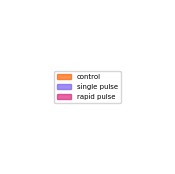

In [6]:
fig, ax = plt.subplots(figsize=(2, 2))

change_font(font_size=5)
# Create dummy handles for your legend entries
handles = [
    mpl.patches.Patch(color=conditionz_colorz[idx], label=time_conditionz_namez[idx], linestyle='solid', alpha=.7)
    for idx in range(3)
]

ax.legend(handles=handles, loc='center')
ax.axis('off')  # hide the empty axes

# plt.tight_layout()
plt.savefig(os.path.join(to_save_dir, 'Conditions_Legend.svg'.format(fish_label)), dpi=600)

plt.show()

0.0 0.0 4.0
0.0 0.0 3.0
0.0 0.0 2.0


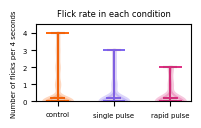

In [7]:
plt.close()

hline_width = .2
change_font(font_size=5)

binz_dict = {} #keeps track of binz distributions so that I can compare the conditions to each other

plt.figure(figsize=(2, 1))
for idx, conditionID in enumerate(time_conditionz_namez):
    conditionID_flicks = conditionz_dict[conditionID]['all flicks']
    conditionID_window = conditionz_dict[conditionID]['window']
    T_binz = [] #binning how many tail flicks happened in T-second bins

    for window0 in range(conditionID_window[0], conditionID_window[1], T):
        # print(window0)
        flicks_in_bin = [flickID for flickID in conditionID_flicks if (flickID >= window0) and (flickID < window0+T)]
        # print(flicks_in_bin)
        T_binz.append(len(flicks_in_bin))

    binz_dict[conditionID] = T_binz
    violin_parts = plt.violinplot(np.array(T_binz), positions=[idx+1], showmeans=True)
    
    quartile1, medians, quartile3 = np.percentile(np.array(T_binz), [0, 50, 100])
    means = np.mean(np.array(T_binz))
    print(quartile1, medians, quartile3)
    plt.vlines(idx+1, ymax=quartile3, ymin=quartile1, color = conditionz_colorz[idx], linewidth=1.35)
    plt.hlines(quartile1, xmax=idx+1+hline_width, xmin=idx+1-hline_width, color = conditionz_colorz[idx], linewidth=1.35)
    plt.hlines(quartile3, xmax=idx+1+hline_width, xmin=idx+1-hline_width, color = conditionz_colorz[idx], linewidth=1.35)
    plt.hlines(means, xmax=idx+1+(hline_width/1.5), xmin=idx+1-(hline_width/1.5), color = conditionz_colorz[idx], linewidth=1.35)
    
    for pc in violin_parts['bodies']:
        pc.set_facecolor(conditionz_colorz[idx])
        # pc.set_edgecolor(conditionz_colorz[idx])
        pc.set_alpha(.25)
        pc.set_edgecolors(conditionz_colorz[idx])
        pc.set_linewidths(3)
        # pc.set_facecolors('white')
    # plt.scatter(np.ones((len(T_binz)))*(idx+1), np.array(T_binz), alpha=.5, label='1 bin', color=conditionz_colorz[idx], s=20)


# padding_line = .1
# line_height = .175
# linewidth = .75

# #control vs rapid pulse 
# plt.vlines([1, 3], ymin = np.max(np.array(binz_dict['control']))+padding_line, ymax = np.max(np.array(binz_dict['control'])) + line_height + padding_line, colors='black', linewidth=linewidth)
# # plt.vlines(3, ymin = np.max(np.array(binz_dict['control']))+padding_line, ymax = np.max(np.array(binz_dict['control'])) + line_height, colors='black')
# plt.hlines(np.max(np.array(binz_dict['control'])) + padding_line + line_height , xmin = 1,  xmax=3, colors='black', linewidth=linewidth)
# star_x = (3+1) / 2
# star_y_padding = 0
# star_y = np.max(np.array(binz_dict['control'])) + line_height + padding_line + star_y_padding
# plt.text(star_x, star_y, '***')

# ---------------

# control_vs_single_padding = .6


# # control vs single pulse 
# plt.vlines([1, 2], ymin = np.max(np.array(binz_dict['control']))+padding_line+control_vs_single_padding, ymax = np.max(np.array(binz_dict['control'])) + line_height + padding_line + control_vs_single_padding, colors='black', linewidth=linewidth)
# # plt.vlines(3, ymin = np.max(np.array(binz_dict['control']))+padding_line, ymax = np.max(np.array(binz_dict['control'])) + line_height, colors='black')
# plt.hlines(np.max(np.array(binz_dict['control'])) + padding_line + line_height + control_vs_single_padding, xmin = 1,  xmax=2, colors='black', linewidth=linewidth)
# star_x = (1+2) / 2
# star_y_padding = 0
# star_y = np.max(np.array(binz_dict['control'])) + line_height + padding_line + star_y_padding + control_vs_single_padding
# plt.text(star_x, star_y, '*')

# ---------------

# single_vs_rapid_padding = .6

# #single pulse vs rapid pulse 
# plt.vlines([2, 3], ymin = np.max(np.array(binz_dict['control']))+padding_line+single_vs_rapid_padding, ymax = np.max(np.array(binz_dict['control'])) + line_height + padding_line + single_vs_rapid_padding, colors='black', linewidth=linewidth)
# # plt.vlines(3, ymin = np.max(np.array(binz_dict['control']))+padding_line, ymax = np.max(np.array(binz_dict['control'])) + line_height, colors='black')
# plt.hlines(np.max(np.array(binz_dict['control'])) + padding_line + line_height + single_vs_rapid_padding, xmin = 2,  xmax=3, colors='black', linewidth=linewidth)
# star_x = (2+3) / 2
# star_y_padding = 0
# star_y = np.max(np.array(binz_dict['control'])) + line_height + padding_line + star_y_padding + single_vs_rapid_padding
# plt.text(star_x, star_y, '***')


# ---------------

plt.xticks(np.arange(start=1, stop=len(time_conditionz_namez)+1, step=1), time_conditionz_namez)


# plt.xlabel(example_condition)
plt.ylabel('Number of flicks per {0} seconds'.format(T))
plt.ylim(0, 4.5)
plt.title('Flick rate in each condition')
plt.savefig(os.path.join(to_save_dir, '{0}_violin_plot.svg'.format(fish_label)), dpi=600)
# plt.legend()

In [8]:
# Calculate p value from two conditions compared to each other 
conditionA = 'single pulse'
conditionB = 'control'

p_value = mannwhitneyu(binz_dict[conditionA], binz_dict[conditionB], axis=0, method='exact').pvalue

print('{0} vs. {1} | p value: {2}'.format(conditionA, conditionB, p_value))

single pulse vs. control | p value: 0.8883689295021482


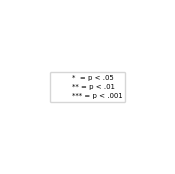

In [9]:
plt.close()

fig, ax = plt.subplots(figsize=(2, 2))

starz = ['*  = p < .05', '** = p < .01', '*** = p < .001']

change_font(font_size=5)
# Create dummy handles for your legend entries
handles = [
    mpl.patches.Patch(color='None', label=starz[idx], linewidth=0.01, linestyle=linestylez[idx])
    for idx in range(len(time_conditionz_namez))
]

ax.legend(handles=handles, loc='center')
ax.axis('off')  # hide the empty axes

# plt.tight_layout()
plt.savefig(os.path.join(to_save_dir, 'p_value_legend.svg'.format(fish_label)), dpi=600)
plt.show()

To calculate the probability of one or more tail flicks occuring, can calculate the CDF value for the lambda value, which will give the probability:

$$
P(\geq1 \ \rm{flick} \ \rm{in} \ \rm{window} \  T) = 1 - e^{-\lambda T}
$$

"CDF stands for cumulative distribution function. The CDF complements the Probability Density Function and provides a cumulative view of the probabilities linked to a random variable. Unlike the smooth curve of the PDF, the CDF appears as a step function, jumping at specific values. It shows the probability that a random variable will be less than or equal to a given value" - [geekforgeeks]('https://www.geeksforgeeks.org/maths/cdf-vs-pdf-what-is-the-difference/')

In [10]:
# finding the average number of flicks for the control condition, and then looking at the probability that the flicks more than x times in a 5 minute window ...

control_avg_T_binz = np.mean(np.array(binz_dict['control']))
print('Average number of flicks in window during control condition: ', control_avg_T_binz)

Average number of flicks in window during control condition:  0.23030303030303031


In this particular situation, the tail flicks are a discrete distribution, and so if I want to see the likelihood that the tail flicks more or less than some value $x$ in a condition, then I can use the CDF to achieve the step-wise non-decreasing function and calculate the probability: 

$$
F(x) = \sum_{x_i \leq x} p_i
$$

Meaning the sum of probabilities $p_i$ at each step $x$

To find $p_i$, we can define it as:

$$
P(X=x_i) = p_i
$$

l  0.21515151515151515
p  0.5770943018503027
l  0.16483516483516483
p  0.4828077720385231
l  0.16666666666666666
p  0.486582880967408


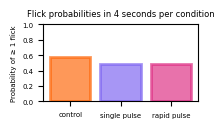

In [11]:
plt.close()

probabilitiez = []

for idx, conditionID in enumerate(time_conditionz_namez):
    conditionID_flicks = conditionz_dict[conditionID]['binarized flicks']
    conditionID_window = conditionz_dict[conditionID]['window']
    T_binz = [] #binning how many tail flicks happened in T-second bins

    for window0 in range(conditionID_window[0], conditionID_window[1], T):
        # print(window0)
        flicks_in_bin = [flickID for flickID in conditionID_flicks if (flickID >= window0) and (flickID < window0+T)]
        # print(flicks_in_bin)
        T_binz.append(len(flicks_in_bin))

    lambda_value = np.sum(np.array(T_binz)) / len(T_binz)
    print('l ', lambda_value)
    probability_of_one_or_more_tail_flicks_in_T =  1 - np.exp(-1*lambda_value*T)
    print('p ', probability_of_one_or_more_tail_flicks_in_T)

    probabilitiez.append(probability_of_one_or_more_tail_flicks_in_T)

plt.figure(figsize=(2, 1))
plt.bar(range(1, len(probabilitiez)+1), probabilitiez, color=conditionz_colorz, alpha=.65, linewidth=2, edgecolor=conditionz_colorz)
change_font(font_size=5)
plt.xticks(np.arange(start=1, stop=len(time_conditionz_namez)+1, step=1), time_conditionz_namez)
# plt.xlabel(example_condition)
plt.title('Flick probabilities in {0} seconds per condition'.format(T))
plt.ylim(0, 1)
plt.ylabel('Probability of ≥ 1 flick')
# plt.legend()
plt.savefig(os.path.join(to_save_dir, '{0}_bar_plot.svg'.format(fish_label)), dpi=600)

In [12]:
probabilitiez

[np.float64(0.5770943018503027),
 np.float64(0.4828077720385231),
 np.float64(0.486582880967408)]

##### Using PMF and CDF as means of calculating probabilities of tail activity as a way of looking at how tail activity might be impacted (help from Claude). Assumes I want to look at activity in 2-min windows. 

Given an observed mean rate $\lambda$ (average flicks per 2-min window) 

$$
P(X = k)
= \frac{e^{-\lambda}\lambda^k}{k!} \; \rm{(PMF)}
$$

$$
P(X \leq k)
= \sum_{k=0}^{x} \frac{e^{-\lambda}\lambda^k}{k!} \; \rm{(CDF)}
$$

$$
P(X>x)=1 - P(X \leq x) \; \rm{(Likelihood \: of \: more \: than \:} x \rm{\:flicks \:happening \:in \: a \: 2 \: minute \: window)}
$$

Where $\lambda$ = total flicks $\div$ number of 2-min windows in that condition

In [13]:
# CDF_k = 5 #number of tail flicks parameter to calulate the CDF function result

probabilitiez = {}
CDF_conditionz = {}
CDF_k_distribution = {}
sorted_T_binz_dict = {}
y_T_binz_dict = {}

for idx, conditionID in enumerate(time_conditionz_namez):
    print(conditionz_dict[conditionID])
    conditionID_flicks = conditionz_dict[conditionID]['all flicks']
    conditionID_window = conditionz_dict[conditionID]['window']
    T_binz = [] #binning how many tail flicks happened in T-second bins
    
    for window0 in range(conditionID_window[0], conditionID_window[1], T):
        # print(window0)
        flicks_in_bin = [flickID for flickID in conditionID_flicks if (flickID >= window0) and (flickID < window0+T)]
        # print(flicks_in_bin)
        T_binz.append(len(flicks_in_bin))

    max_flicks_in_bin = np.max((T_binz))
    print('max is ', max_flicks_in_bin)
    lambda_value = np.sum(np.array(T_binz)) / (len(T_binz))
    print('l ', lambda_value)
    sorted_T_binz = np.sort(np.array(T_binz))
    y_T_binz = np.arange(1, len(sorted_T_binz) + 1) / len(sorted_T_binz)
    
    CDF_k_prob = []
    
    for flick_k in range(max_flicks_in_bin+1): #+1 to include max
        pmf_k = (np.exp(-1*lambda_value)*(lambda_value**flick_k))/(scipy.special.factorial(flick_k))
        CDF_k_prob.append(pmf_k)

    sorted_T_binz_dict[conditionID] = sorted_T_binz
    y_T_binz_dict[conditionID] = y_T_binz
    
    CDF_conditionz[conditionID] = np.cumsum(CDF_k_prob)
    CDF_k_distribution[conditionID] = CDF_k_prob

{'window': (600, 1919), 'all flicks': [684, 875, 877, 911, 912, 973, 974, 975, 1090, 1091, 1124, 1207, 1210, 1211, 1212, 1310, 1311, 1313, 1828, 1839, 1855, 641, 653, 654, 655, 793, 876, 913, 972, 980, 1033, 1034, 1122, 1123, 1206, 1285, 1286, 1309, 1312, 1315, 1378, 1379, 1426, 1427, 1428, 1429, 1457, 1459, 1427, 1428, 1429, 1457, 1459, 1474, 1476, 1518, 1697, 1698, 1699, 1727, 1767, 1768, 1770, 1787, 1788, 1829, 1838, 1853, 1854, 1863, 1903, 695, 1138, 1529, 1827, 1864], 'binarized flicks': [684, 875, 877, 911, 912, 973, 974, 975, 1090, 1091, 1124, 1207, 1210, 1211, 1212, 1310, 1311, 1313, 1828, 1839, 1855, 641, 653, 654, 655, 793, 876, 913, 972, 980, 1033, 1034, 1122, 1123, 1206, 1285, 1286, 1309, 1312, 1315, 1378, 1379, 1426, 1427, 1428, 1429, 1457, 1459, 1427, 1428, 1429, 1457, 1459, 1474, 1476, 1518, 1697, 1698, 1699, 1727, 1767, 1768, 1770, 1787, 1788, 1829, 1838, 1853, 1854, 1863, 1903]}
max is  4
l  0.23030303030303031
{'window': (1919, 2283), 'all flicks': [1950, 2007, 2094, 

In [14]:
sorted_T_binz_fname = os.path.join(home_dir, 'tail_sorted_T_binz_{0}.pkl'.format(fish_label))
y_T_binz_fname = os.path.join(home_dir, 'tail_y_T_binz_{0}.pkl'.format(fish_label))

with open(sorted_T_binz_fname, 'wb') as f:
    pickle.dump(sorted_T_binz_dict, f)
    f.close()

with open(y_T_binz_fname, 'wb') as f:
    pickle.dump(y_T_binz_dict, f)
    f.close()

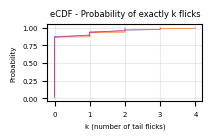

In [15]:
plt.close()
change_font(font_size=5)

plt.figure(figsize=(2, 1))

for idx, conditionID in enumerate(time_conditionz_namez):
    plt.plot(sorted_T_binz_dict[conditionID], y_T_binz_dict[conditionID], color=conditionz_colorz[idx], alpha=.9, linewidth=.5)
    # break
# plt.xticks(np.arange(start=1, stop=len(time_conditionz_namez)+1, step=1), time_conditionz_namez)
# plt.xlabel(example_condition)
plt.title('eCDF - Probability of exactly k flicks')
# plt.ylim(0, 1)
plt.ylabel('Probability')
plt.grid(visible=True, which='both', alpha=.25)

plt.xlabel('k (number of tail flicks)')
# plt.grid(visible=True, which='both', alpha=.5)
# plt.xticks(np.arange(start=0, stop=300, step=20))
# plt.vlines([5], ymin=0, ymax=1, linestyle='dashed', color='grey', alpha=.75, linewidth=2)
plt.savefig(os.path.join(to_save_dir, '{0}_ecdf_plot.svg'.format(fish_label)), dpi=600)
# plt.legend()

### Observing the percentage of responses to the stimulus onsets 

In [16]:
#USER INPUTTED PARAMETERS
experimental_schematic_fname = os.path.join(home_dir, 'Experimental_Schematic', 'spring_2025_schematic.npy') # numpy schematic that I generated from the "Audio_Schematic_Array_Creator.ipynb
experimental_schematic = np.load(experimental_schematic_fname)

#Load the experiment array to get the time points where the stimulus is on
event_time_points = np.where(experimental_schematic!=0)[0]#time points where the stimulus is on
print('Time points with stimulus onset: {0}'.format(event_time_points))

Time points with stimulus onset: [1919 2039 2159 2279 2283 2287 2291 2295 2299 2303 2307 2311 2315 2319
 2323 2327 2331 2335 2339 2343 2347 2351 2355 2359 2363 2367 2371 2375
 2379 2383 2387 2391 2395 2399]


In [17]:
# Because I am now interested in response to the stimuli, I am loading the array that I generated from the 
# "Audio_Schematic_Array_Creator.ipynb"

In [18]:
response_percentage = {}
response_percentage_fname = os.path.join(home_dir, 'tail_response_percentage_{0}.pkl'.format(fish_label))

stimulus_condition_namez = ['single pulse', 'rapid pulse']

for idx, conditionID in enumerate(stimulus_condition_namez):
    conditionID_flicks = conditionz_dict[conditionID]['all flicks']
    conditionID_window0, conditionID_window1  = conditionz_dict[conditionID]['window']
    
    window_event_time_points = event_time_points[np.where((event_time_points<conditionID_window1)&(event_time_points>=conditionID_window0))[0]]
    total_events = len(window_event_time_points)
    response_flicks_idx = np.where(np.isin(conditionID_flicks, window_event_time_points))[0]
    print(np.array(conditionID_flicks)[response_flicks_idx])
    print(response_flicks_idx)
    n_response_flicks = len(response_flicks_idx)
    response_percentage[conditionID] = (np.array(n_response_flicks) / np.array(total_events)) * 100
    print('----------------------------------------')

with open(response_percentage_fname, 'wb') as f:
    pickle.dump(response_percentage, f)
    f.close()

[]
[]
----------------------------------------
[2315 2327]
[1 3]
----------------------------------------


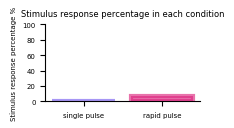

In [19]:
plt.close()
ncols, nrows = 1, 1
figsize = (2,1)
change_font(font_size=5)
volume_cmap = 'gist_gray'
y_tick_steps = 20

fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)

conditions_percentagez = []
conditions_namez = []

for condition_name in response_percentage.keys():
    conditions_percentagez.append(response_percentage[condition_name])
    conditions_namez.append(condition_name)

axs.bar(conditions_namez, conditions_percentagez, color=[conditionz_colorz[1], conditionz_colorz[2]], alpha=.65,  linewidth=3, edgecolor=[conditionz_colorz[1], conditionz_colorz[2]])

axs.set_ylabel('Stimulus response percentage %')
axs.set_title('Stimulus response percentage in each condition')
axs.set_yticks(np.arange(0, 100, ))
# axs.set_ylim(top=12, bottom=-1)
axs.set_yticks(np.arange(start=0, stop=100+1, step=y_tick_steps))

axs.spines[['top', 'right']].set_visible(False)
plt.savefig(os.path.join(to_save_dir, '{0}_response_bar.svg'.format(fish_label)), dpi=600)

plt.show()


# 